In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

TIMEOUT = 300.0  # seconds — runs that exceeded this have NaN in total_duration

big_int_cols = [
    'lost_solutions','removed_solutions','common_solutions','added_solutions',
    'gained_solutions','left_count','left_sliced_count','right_count',
    'right_sliced_count','common_solutions_count','removed_solutions_count',
    'added_solutions_count'
]

csv_path = Path('../../stages-2026-05-18/main/8_diff_with_clausy/output.csv')
df_full = pd.read_csv(csv_path, dtype={c: str for c in big_int_cols})

def extract_system(formula):
    parts = formula.split('/')
    if parts[0].startswith('extract-kconfig-models-with-'):
        return parts[1]
    return parts[0]

df_full['system'] = df_full['left_formula'].apply(extract_system)

df = df_full[df_full['method'] != 'satisfy-simplified'].reset_index(drop=True)

# NaN in total_duration means the run timed out
df['duration_s'] = df['total_duration'] / 1e9
df['diff_mode'] = df['left_diff_kind'].astype(str) + ' / ' + df['right_diff_kind'].astype(str)

systems = sorted(df['system'].unique())
n_total   = len(df)
n_timeout = df['duration_s'].isna().sum()
print(f"{n_total} rows, {n_timeout} timeouts (NaN in total_duration)")
print(f"Systems: {systems}")

8844 rows, 2316 timeouts (NaN in total_duration)
Systems: ['FinancialServices01', 'automotive2', 'buildroot', 'busybox', 'embtoolkit', 'freetz-ng', 'l4re', 'toybox', 'uclibc-ng']


In [2]:
def draw_boxes(ax, labels, series_list, colors=None, rot=0, title=None, xlabel=None, ylabel='Duration (s)'):
    # NaN values represent timeouts; exclude them from boxes but count them
    valid_data = [s[s.notna()].values for s in series_list]
    timeouts   = [int(s.isna().sum()) for s in series_list]
    totals     = [len(s) for s in series_list]

    valid = [(i, l, d, t, tot) for i, (l, d, t, tot) in
             enumerate(zip(labels, valid_data, timeouts, totals)) if tot > 0]
    if not valid:
        ax.set_visible(False)
        return

    positions   = list(range(1, len(valid) + 1))
    v_labels    = [v[1] for v in valid]
    v_data      = [v[2] for v in valid]
    v_timeouts  = [v[3] for v in valid]
    v_totals    = [v[4] for v in valid]

    has_data = [len(d) > 0 for d in v_data]
    bp_pos   = [p for p, h in zip(positions, has_data) if h]
    bp_data  = [d for d, h in zip(v_data, has_data) if h]

    if bp_data:
        bp = ax.boxplot(bp_data, positions=bp_pos, patch_artist=True,
                        flierprops=dict(marker='o', markersize=3, alpha=0.4),
                        widths=0.6)
        if colors is None:
            colors = plt.cm.tab10(np.linspace(0, 1, len(valid)))
        for box, pos in zip(bp['boxes'], bp_pos):
            idx = positions.index(pos)
            c = colors[idx] if hasattr(colors, '__len__') else colors
            box.set_facecolor(c)
            box.set_alpha(0.7)

    ax.axhline(TIMEOUT, color='red', linestyle='--', linewidth=0.9, alpha=0.7, label=f'timeout ({TIMEOUT}s)')
    ax.set_xticks(positions)
    ax.set_xticklabels(v_labels, rotation=rot, ha='right' if rot else 'center')
    ax.set_xlim(0.5, len(valid) + 0.5)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if title:
        ax.set_title(title, fontsize=10)
    if xlabel:
        ax.set_xlabel(xlabel)

    y_lo, y_hi = ax.get_ylim()
    y_hi = max(y_hi, TIMEOUT * 1.2)
    ax.set_ylim(top=y_hi)

    for pos, tot, nt in zip(positions, v_totals, v_timeouts):
        ax.text(pos, y_lo - (y_hi - y_lo) * 0.04,
                f'n={tot}', ha='center', va='top', fontsize=7, color='gray')
        if nt > 0:
            ax.text(pos, TIMEOUT + (y_hi - TIMEOUT) * 0.15,
                    f'{nt}', ha='center', va='bottom', fontsize=8,
                    color='red', fontweight='bold')

    ax.legend(fontsize=7, loc='upper right')


## 1. Nine difference modes (left_diff_kind × right_diff_kind)

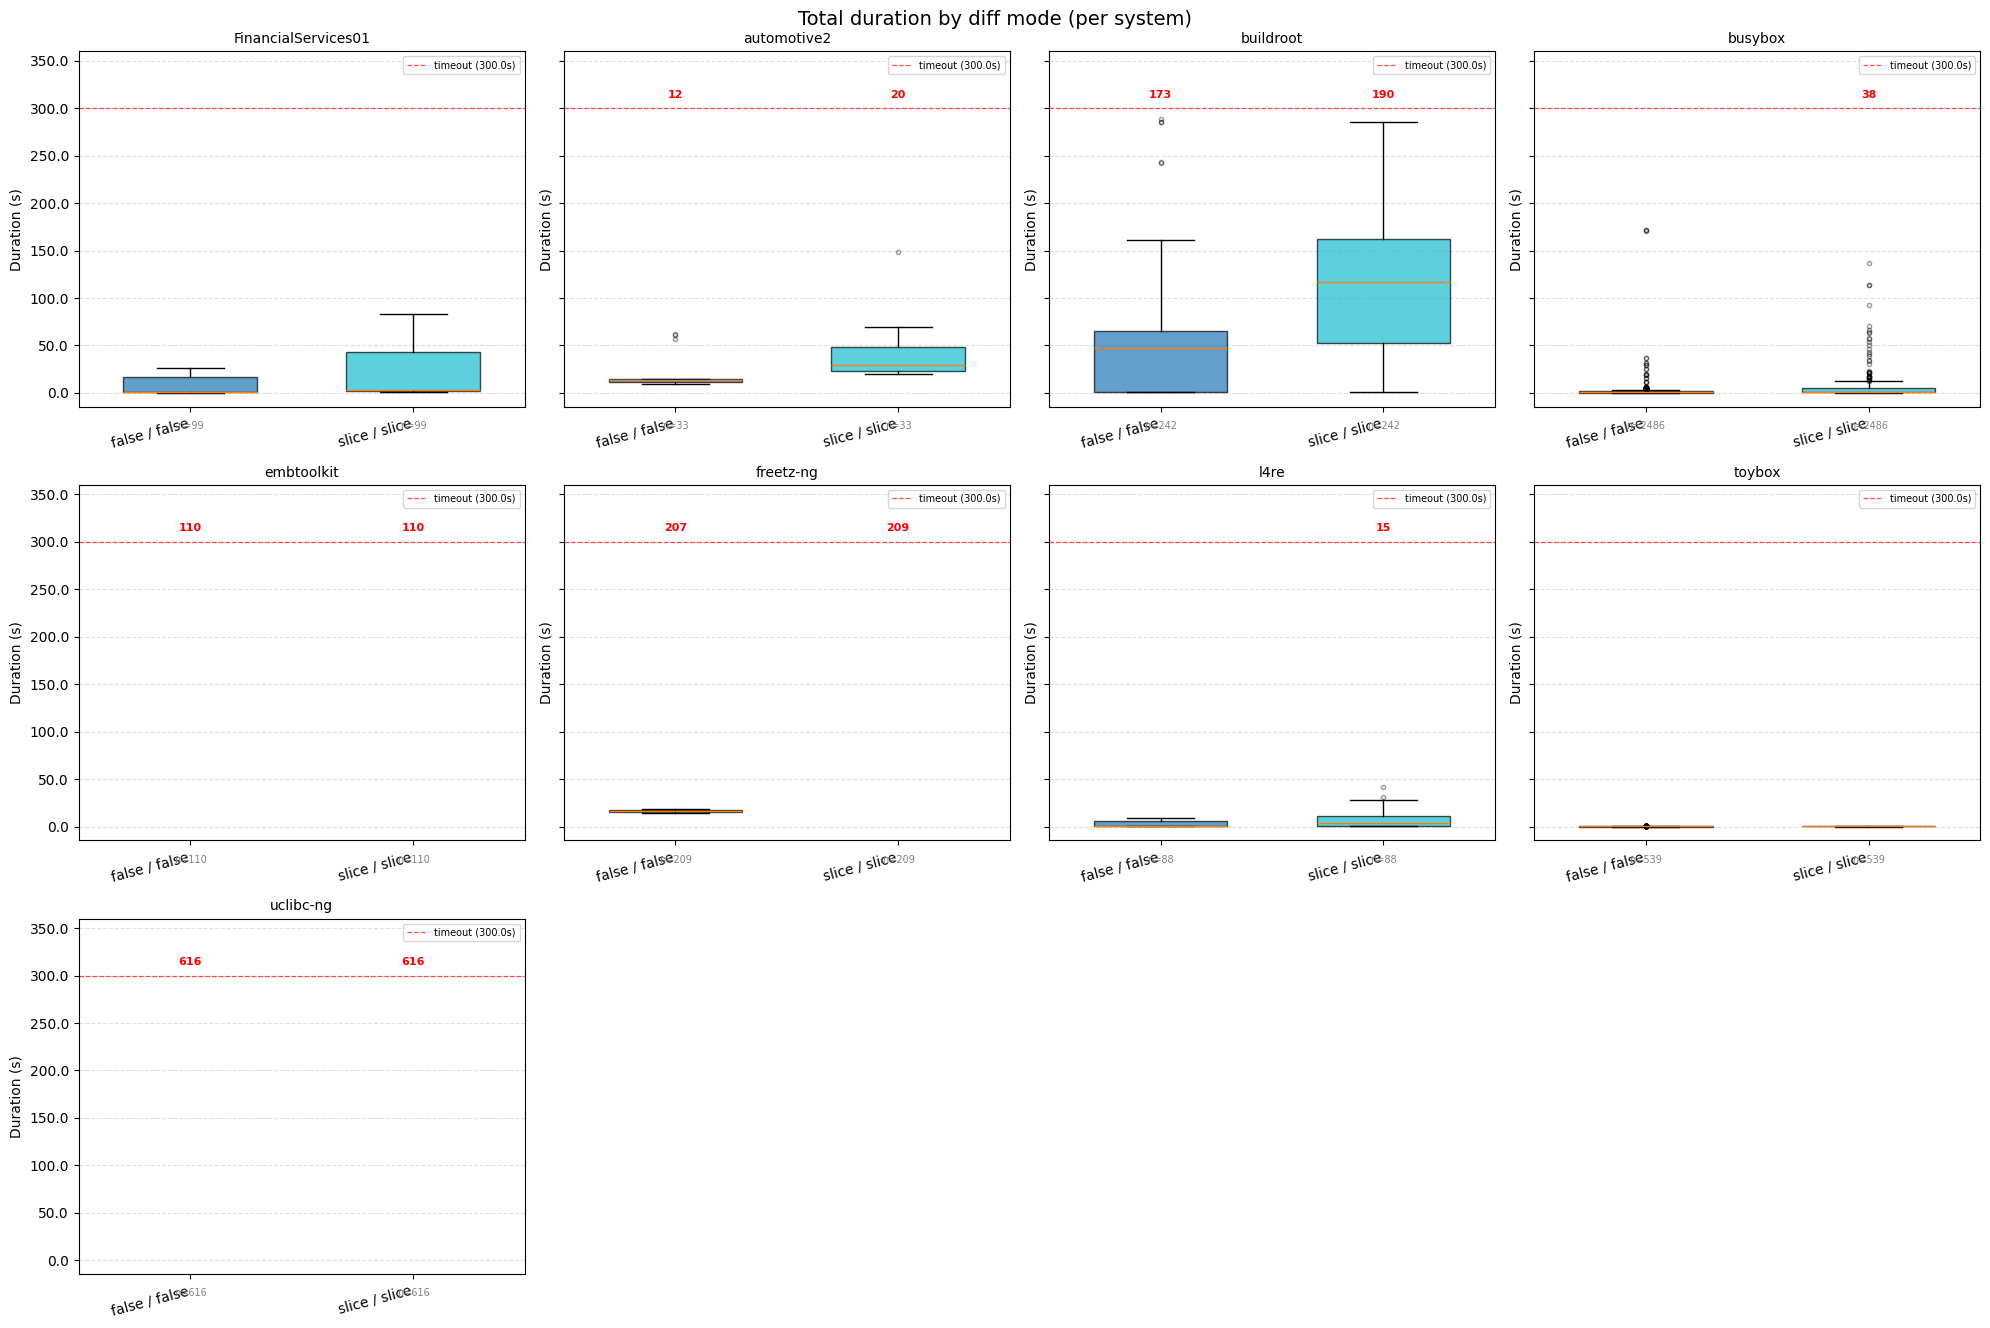

In [3]:
systems   = sorted(df['system'].unique())
all_modes = sorted(df['diff_mode'].unique())
colors    = plt.cm.tab10(np.linspace(0, 1, len(all_modes)))

n_cols = 4
n_rows = int(np.ceil(len(systems) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         sharey=True, squeeze=False)
fig.suptitle('Total duration by diff mode (per system)', fontsize=14)

for idx, system in enumerate(systems):
    ax  = axes[idx // n_cols][idx % n_cols]
    sdf = df[df['system'] == system]
    diff_modes = sorted(sdf['diff_mode'].unique())
    series = [sdf[sdf['diff_mode'] == m]['duration_s'] for m in diff_modes]
    cols   = [colors[all_modes.index(m)] for m in diff_modes]
    draw_boxes(ax, diff_modes, series, colors=cols, rot=15, title=system)

for idx in range(len(systems), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Method × engine combinations (facet by method)

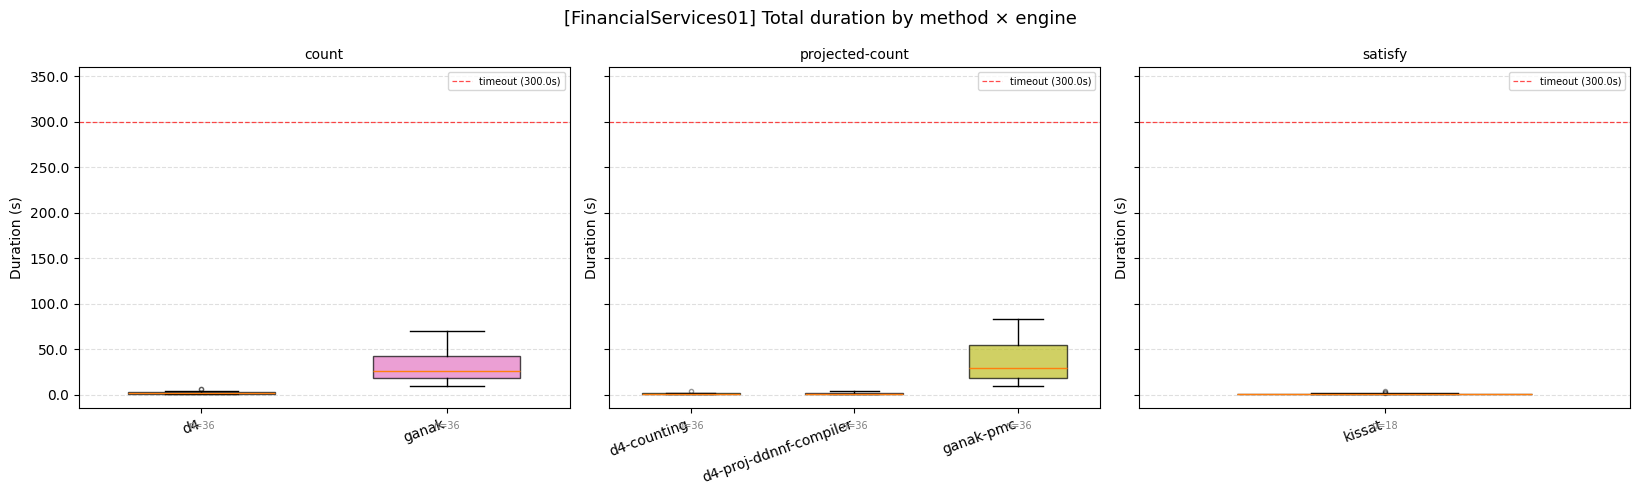

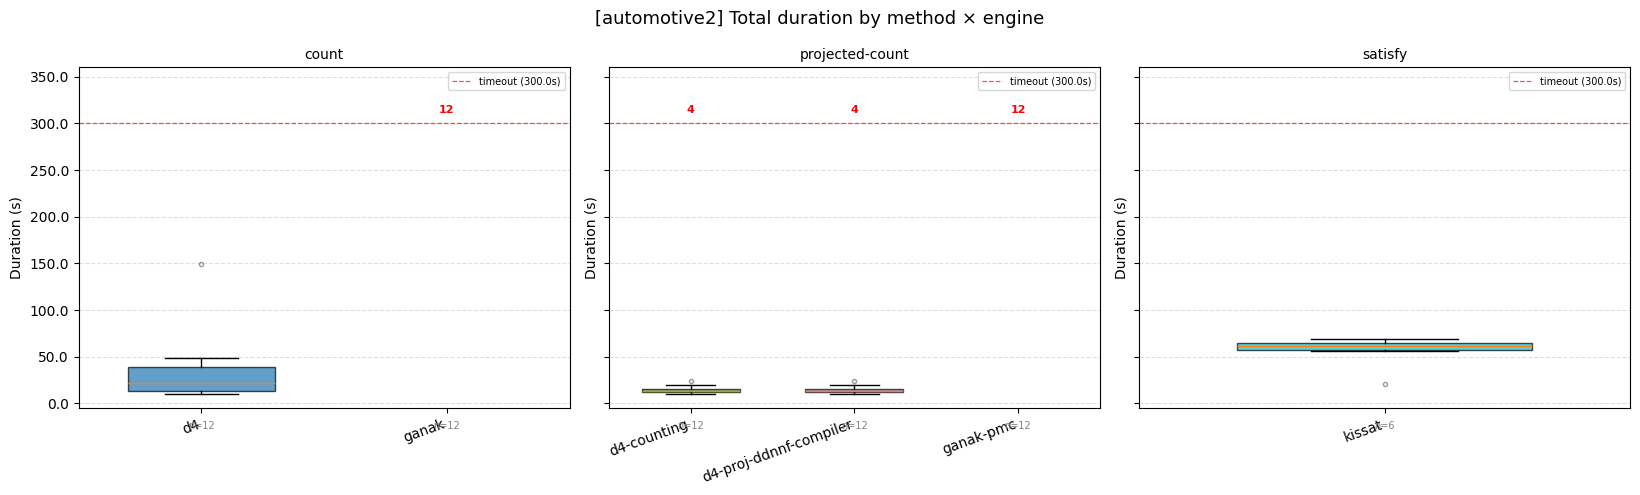

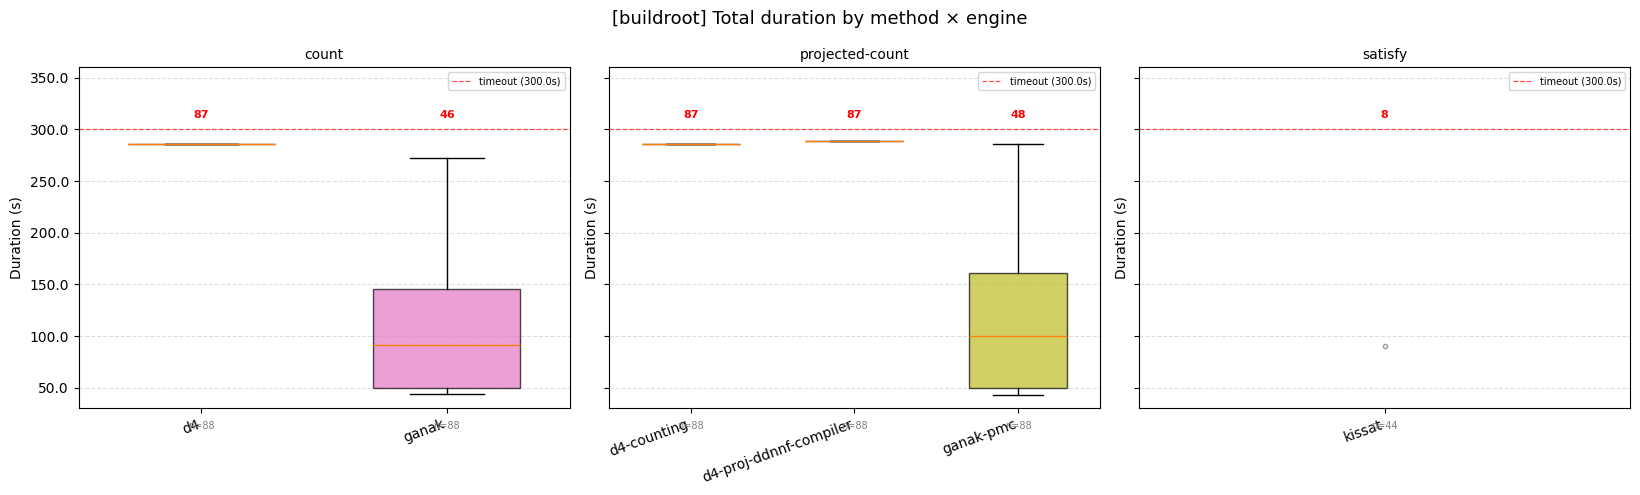

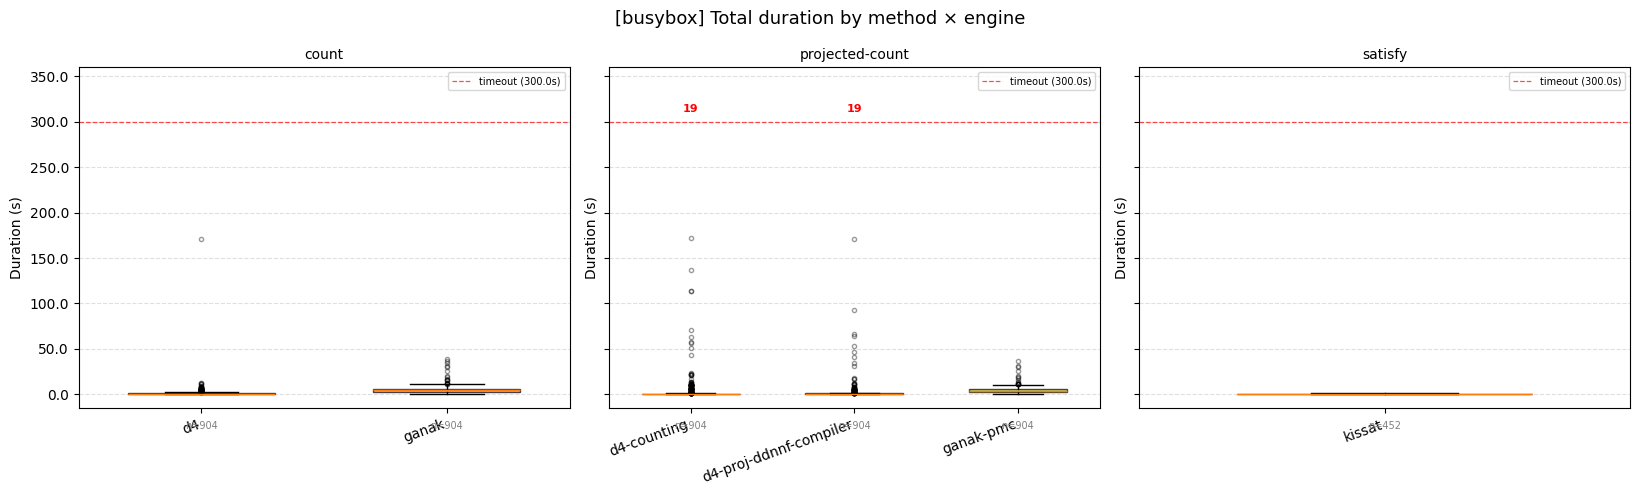

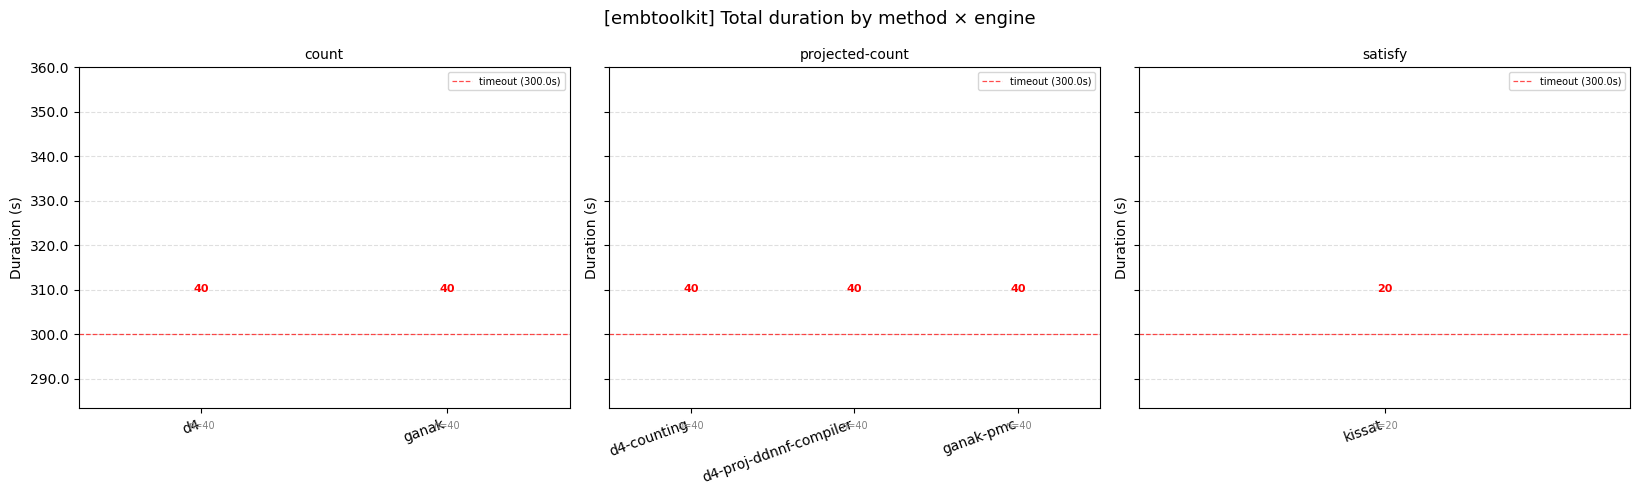

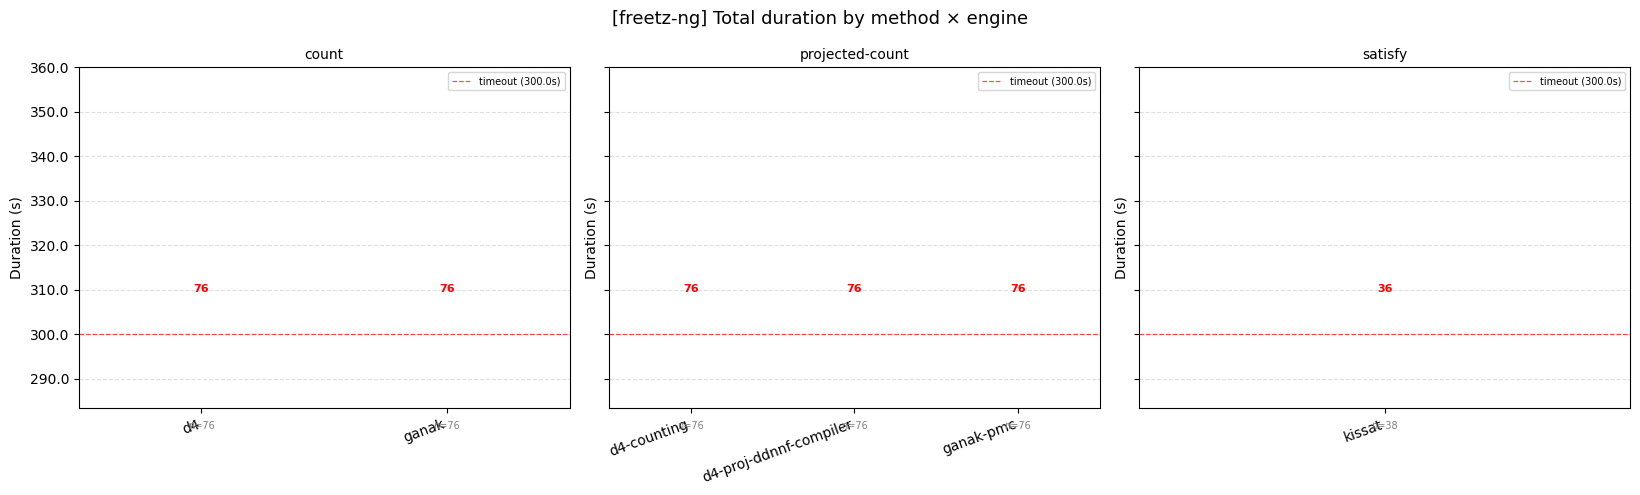

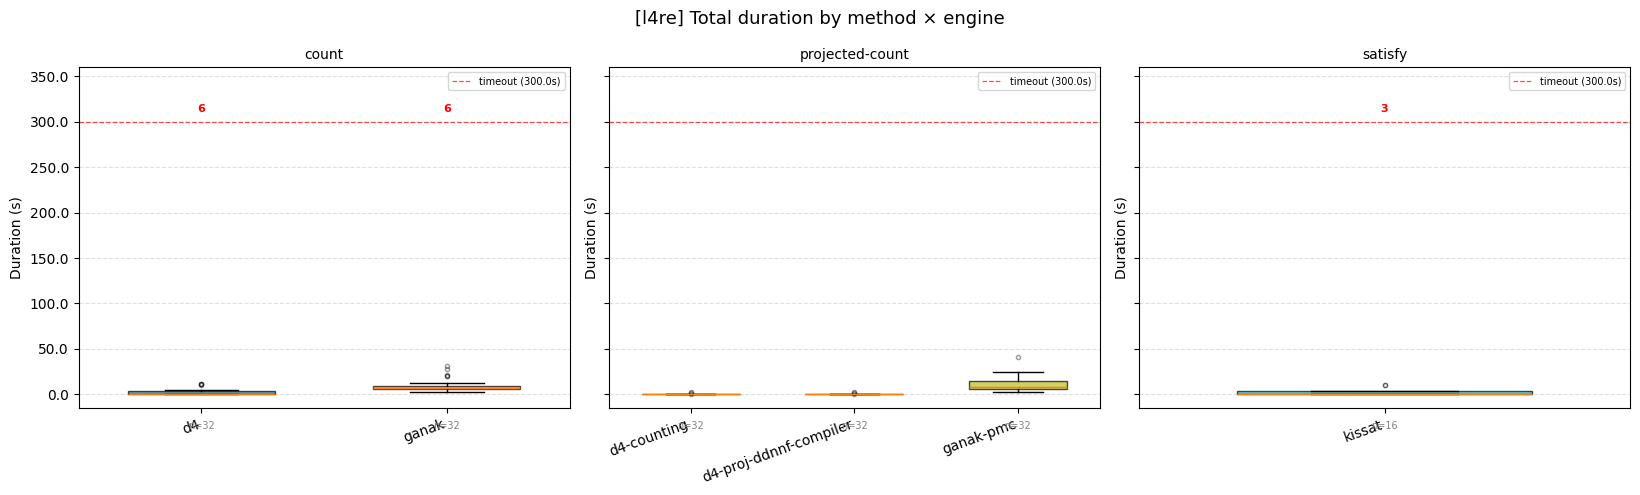

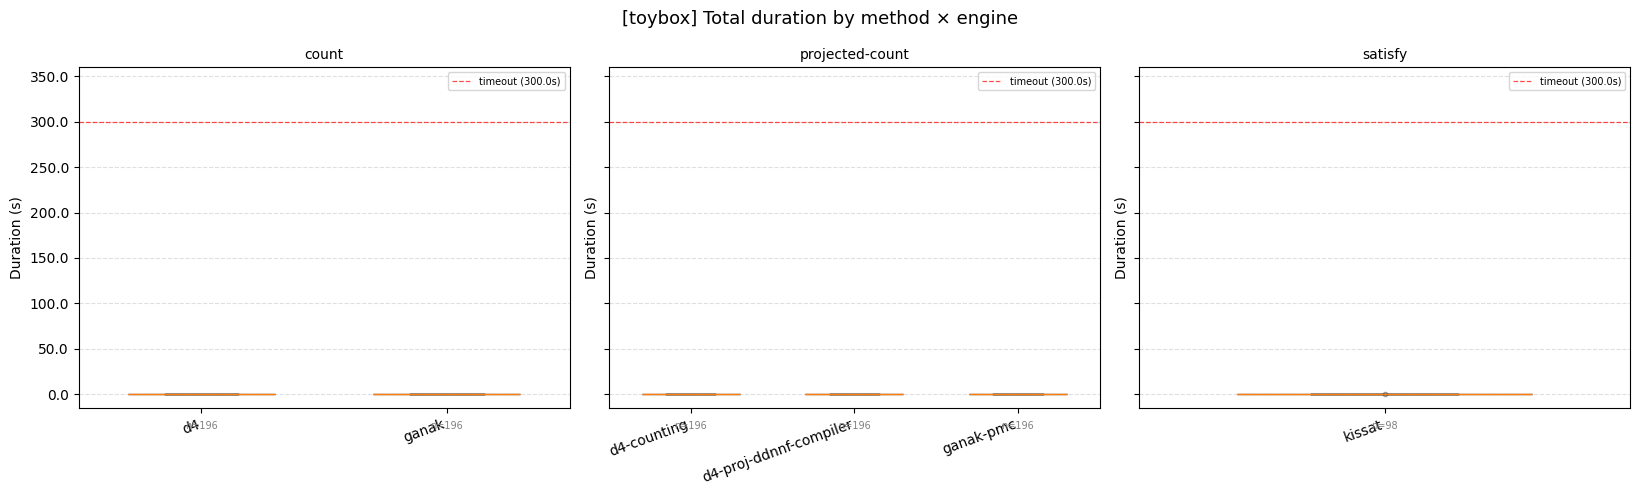

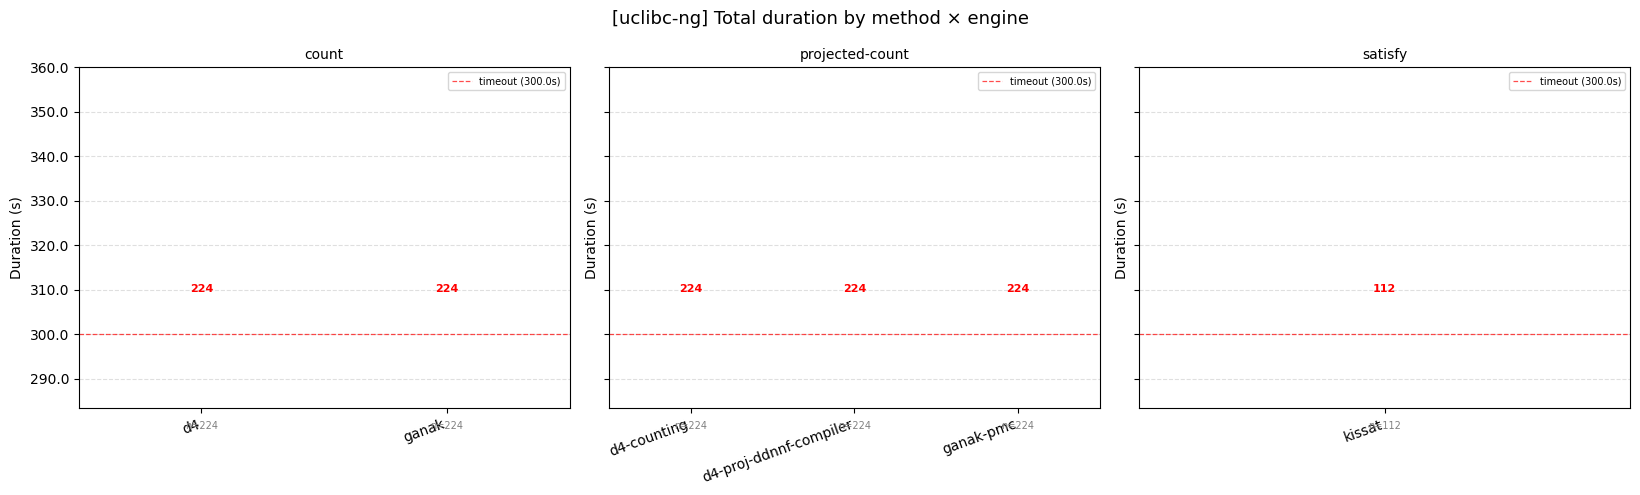

In [4]:
for system, sdf in df.groupby('system'):
    methods = sorted(sdf['method'].unique())
    engines = sorted(sdf['engine'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(engines)))
    engine_color = dict(zip(engines, colors))

    fig, axes = plt.subplots(1, len(methods), figsize=(5.5 * len(methods), 5), sharey=True)
    if len(methods) == 1:
        axes = [axes]
    fig.suptitle(f'[{system}] Total duration by method × engine', fontsize=13)

    for ax, method in zip(axes, methods):
        subset = sdf[sdf['method'] == method]
        present = [e for e in engines if e in subset['engine'].values]
        series = [subset[subset['engine'] == e]['duration_s'] for e in present]
        cols = [engine_color[e] for e in present]
        draw_boxes(ax, present, series, colors=cols, rot=20, title=method)

    plt.tight_layout()
    plt.show()

## 4b. Method × engine — all projects combined (colored by project)

/var/folders/jm/jx4yspgn667320j0_ybbry480000gn/T/ipykernel_44966/3492783957.py:57: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ek/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


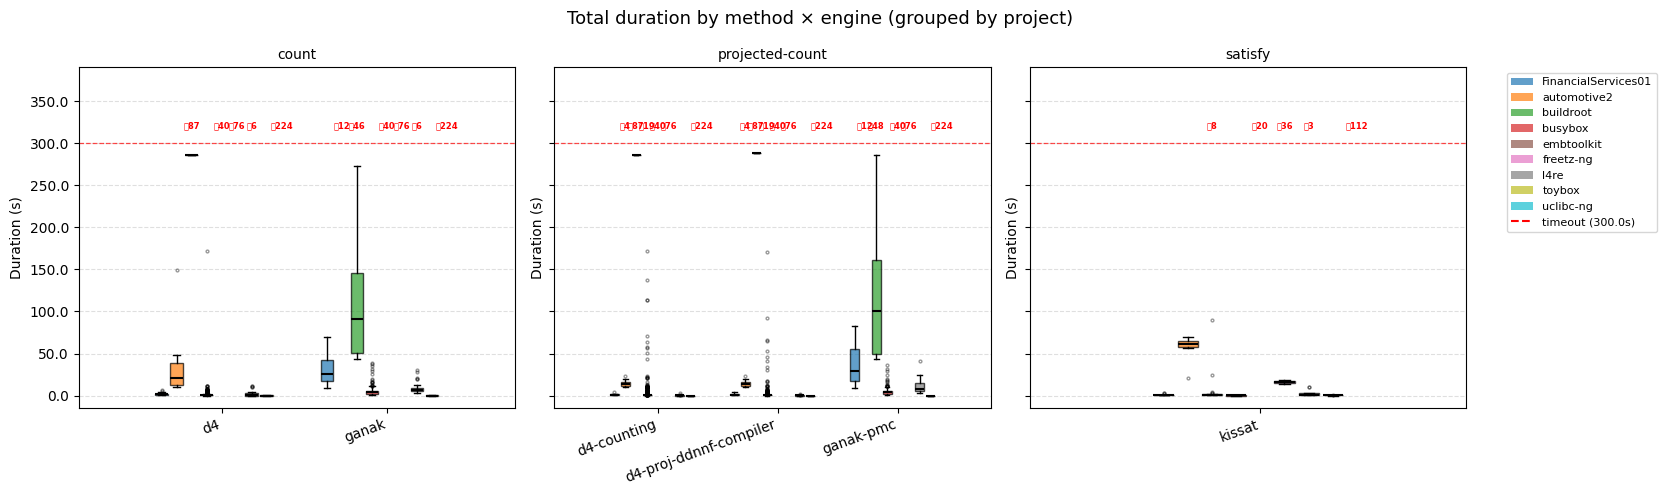

In [5]:
methods  = sorted(df["method"].unique())
systems  = sorted(df["system"].unique())

system_colors = dict(zip(systems, plt.cm.tab10(np.linspace(0, 1, len(systems)))))

n_systems = len(systems)
group_w   = 0.8
box_w     = group_w / n_systems * 0.85
offsets   = np.linspace(-group_w/2 + box_w/2, group_w/2 - box_w/2, n_systems)

fig, axes = plt.subplots(1, len(methods), figsize=(5.5 * len(methods), 5), sharey=True, squeeze=False)
fig.suptitle('Total duration by method × engine (grouped by project)', fontsize=13)

for ax, method in zip(axes[0], methods):
    present_engines = sorted(df[df["method"] == method]["engine"].unique())
    sub_meth = df[df["method"] == method]

    for si, system in enumerate(systems):
        sub = sub_meth[sub_meth["system"] == system]
        for ei, engine in enumerate(present_engines):
            s = sub[sub["engine"] == engine]["duration_s"]
            if len(s) == 0:
                continue
            clipped = s[s.notna()].values
            n_tout  = int(s.isna().sum())
            pos     = ei + 1 + offsets[si]

            if len(clipped) > 0:
                bp = ax.boxplot([clipped], positions=[pos], widths=box_w,
                               patch_artist=True,
                               flierprops=dict(marker='o', markersize=2, alpha=0.4),
                               medianprops=dict(color='black', linewidth=1.5))
                bp['boxes'][0].set_facecolor(system_colors[system])
                bp['boxes'][0].set_alpha(0.7)

            if n_tout > 0:
                ax.text(pos, TIMEOUT + TIMEOUT * 0.05,
                        f'⏱{n_tout}', ha='center', va='bottom',
                        fontsize=6, color='red', fontweight='bold')

    ax.axhline(TIMEOUT, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.set_ylim(top=TIMEOUT * 1.3)
    ax.set_xticks(range(1, len(present_engines) + 1))
    ax.set_xticklabels(present_engines, rotation=20, ha='right')
    ax.set_ylabel('Duration (s)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.set_title(method, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

legend_handles = [
    plt.matplotlib.patches.Patch(facecolor=system_colors[s], alpha=0.7, label=s)
    for s in systems
]
legend_handles.append(plt.Line2D([0], [0], color='red', linestyle='--',
                                   label=f'timeout ({TIMEOUT}s)'))
axes[0][-1].legend(handles=legend_handles, fontsize=8, loc='upper right', bbox_to_anchor=(1.45, 1))
plt.tight_layout()
plt.show()

## 5. CNF transformation (only for satisfy)

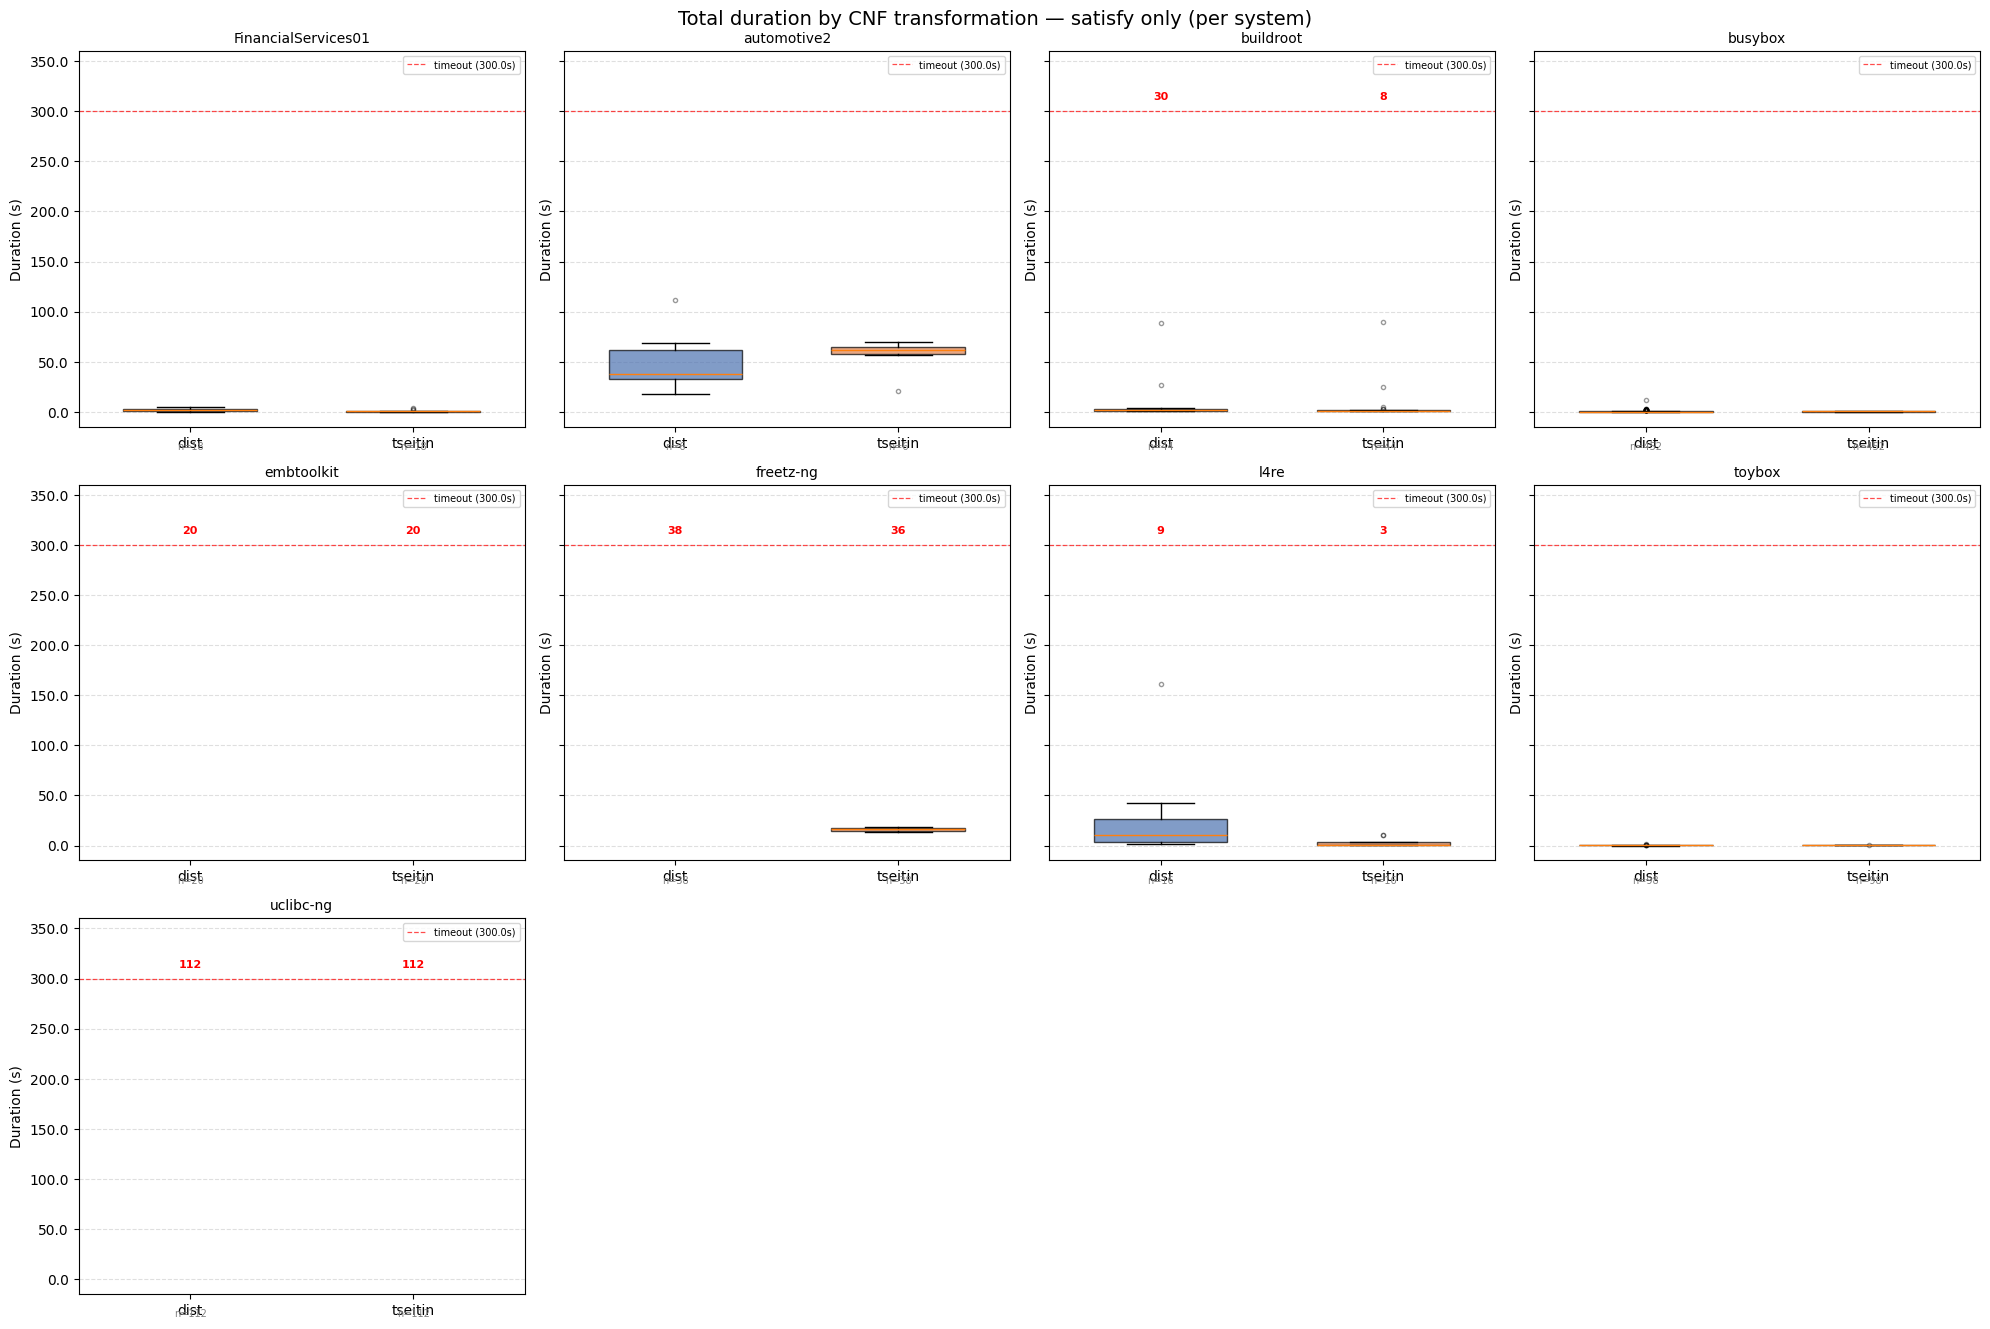

In [6]:
# Re-include satisfy-simplified rows (distributive transform) for this section only
# and restrict to satisfy methods only (tseitin vs dist comparison)
df_sec5 = df_full[df_full['method'].isin(['satisfy', 'satisfy-simplified'])].copy()
df_sec5['duration_s'] = df_sec5['total_duration'] / 1e9

all_transforms = sorted(df_sec5['cnf_transform'].unique())
tr_colors = ['#4C72B0', '#DD8452']

n_cols = 4
n_rows = int(np.ceil(len(systems) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         sharey=True, squeeze=False)
fig.suptitle('Total duration by CNF transformation — satisfy only (per system)', fontsize=14)

for idx, system in enumerate(systems):
    ax  = axes[idx // n_cols][idx % n_cols]
    sdf = df_sec5[df_sec5['system'] == system]
    transforms = sorted(sdf['cnf_transform'].unique())
    series = [sdf[sdf['cnf_transform'] == t]['duration_s'] for t in transforms]
    cols   = [tr_colors[all_transforms.index(t)] for t in transforms]
    draw_boxes(ax, transforms, series, colors=cols, title=system)

for idx in range(len(systems), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Negation

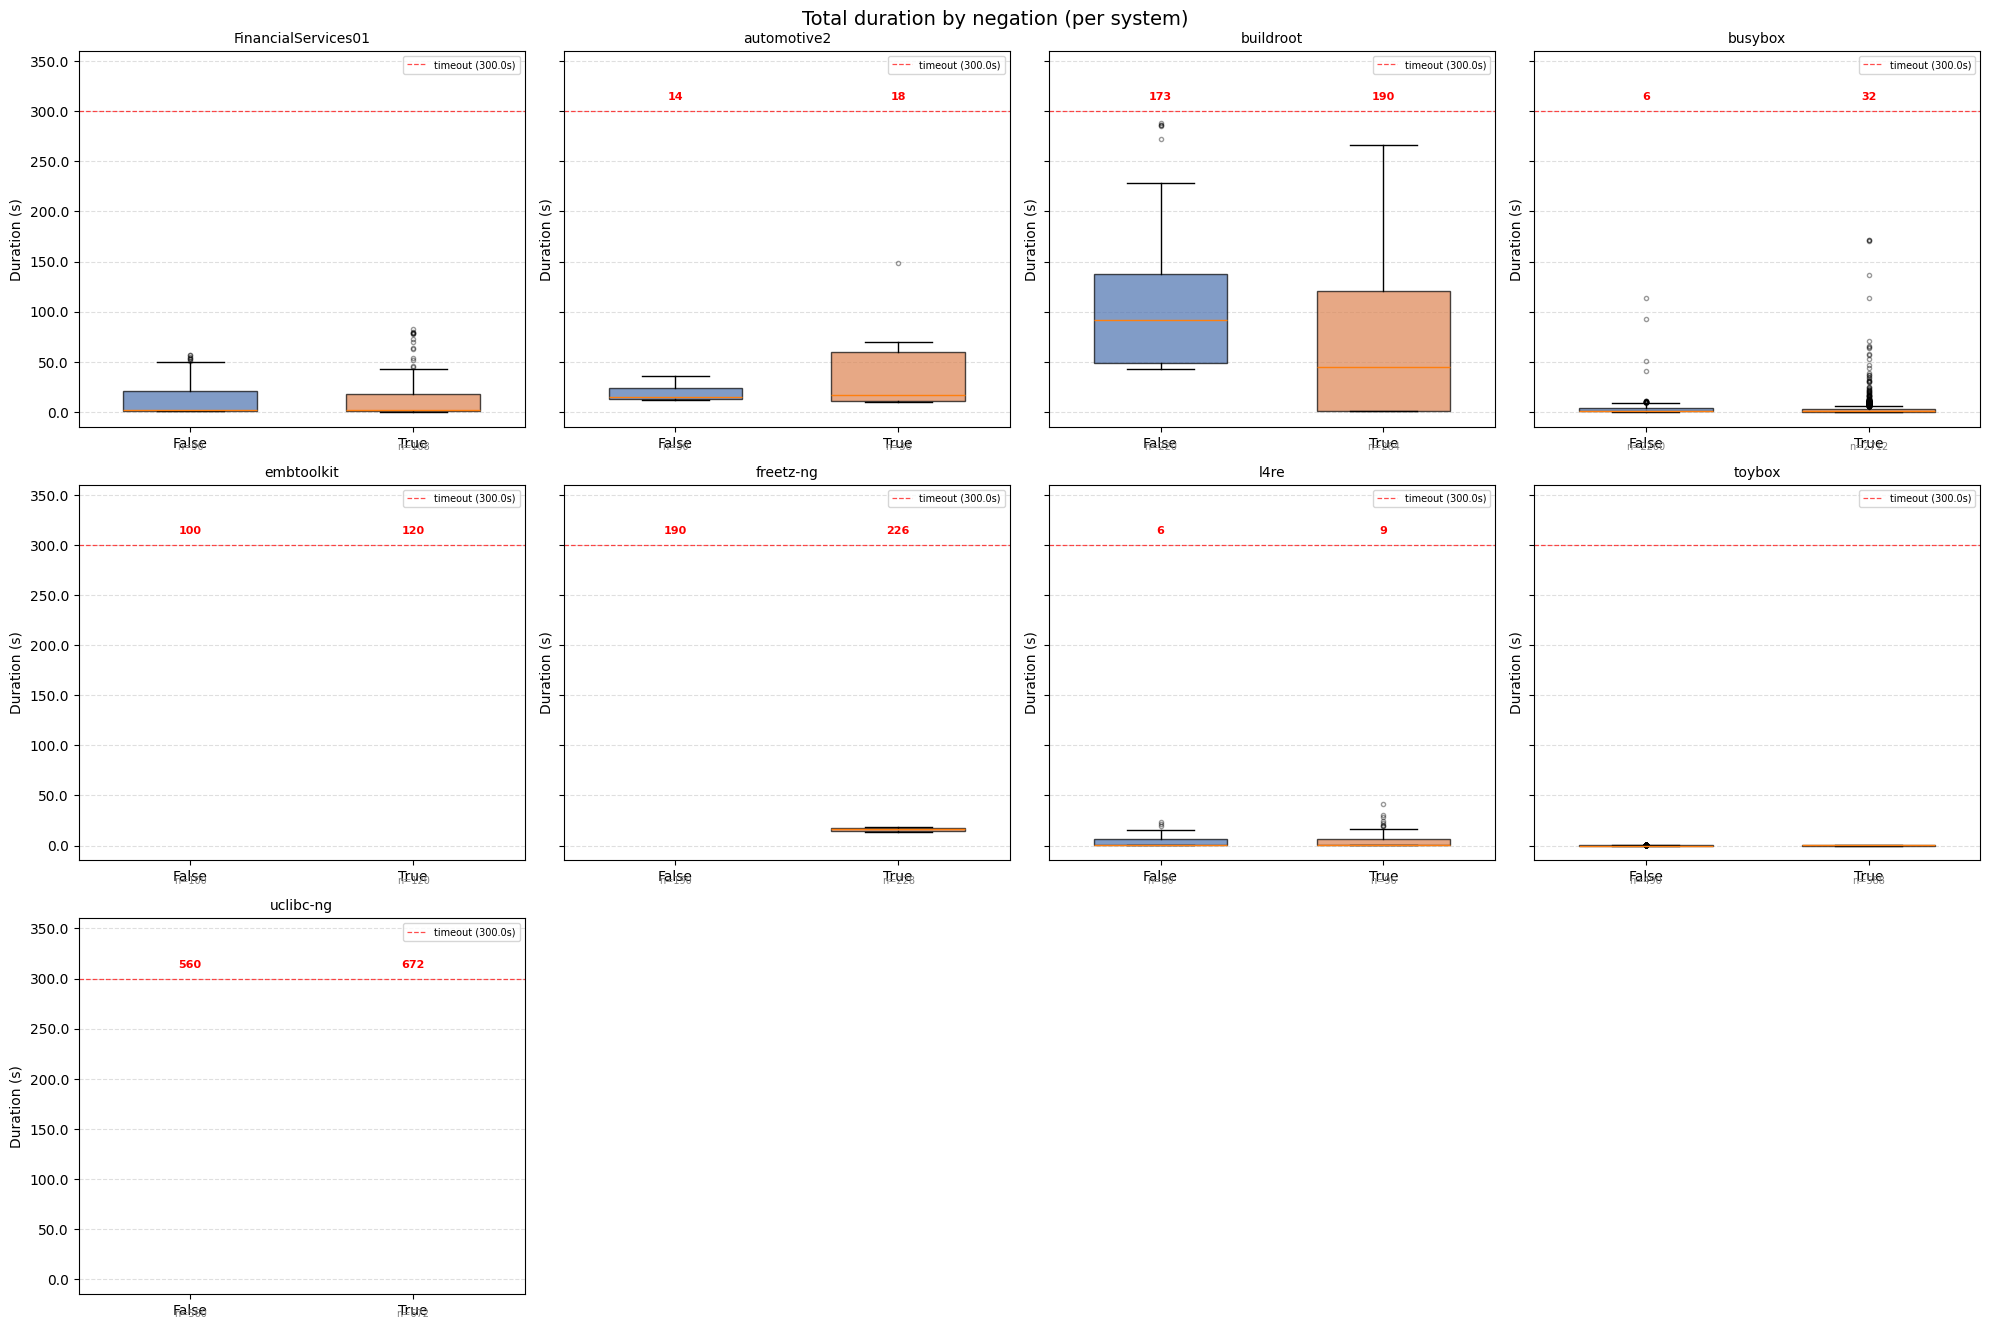

In [7]:
all_neg_vals = sorted(df['negate'].astype(str).unique())
neg_colors = ['#4C72B0', '#DD8452']

n_cols = 4
n_rows = int(np.ceil(len(systems) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         sharey=True, squeeze=False)
fig.suptitle('Total duration by negation (per system)', fontsize=14)

for idx, system in enumerate(systems):
    ax  = axes[idx // n_cols][idx % n_cols]
    sdf = df[df['system'] == system]
    neg_vals = sorted(sdf['negate'].astype(str).unique())
    series = [sdf[sdf['negate'].astype(str) == v]['duration_s'] for v in neg_vals]
    cols   = [neg_colors[all_neg_vals.index(v)] for v in neg_vals]
    draw_boxes(ax, neg_vals, series, colors=cols, title=system)

for idx in range(len(systems), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Solution composition per version pair (removed / common / added)

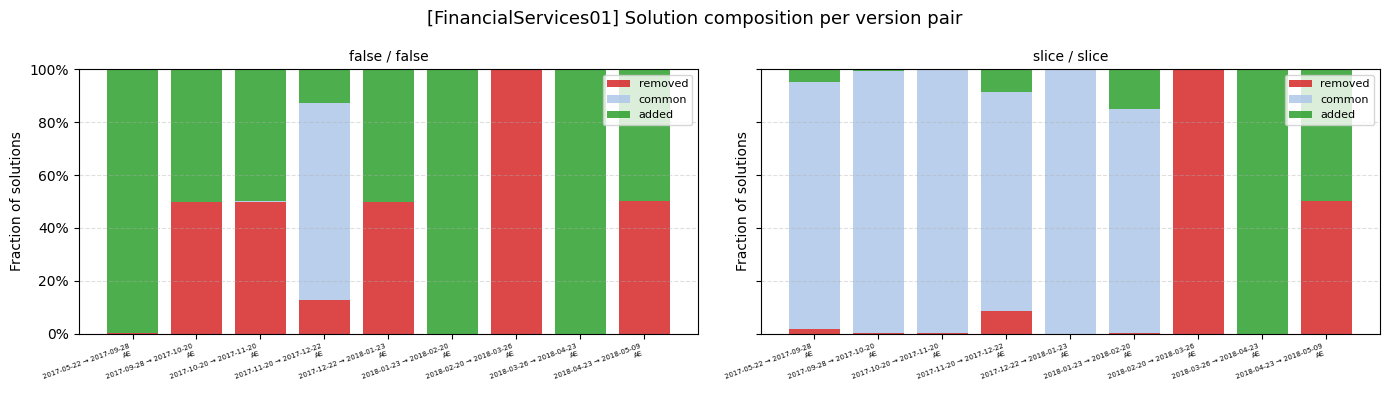

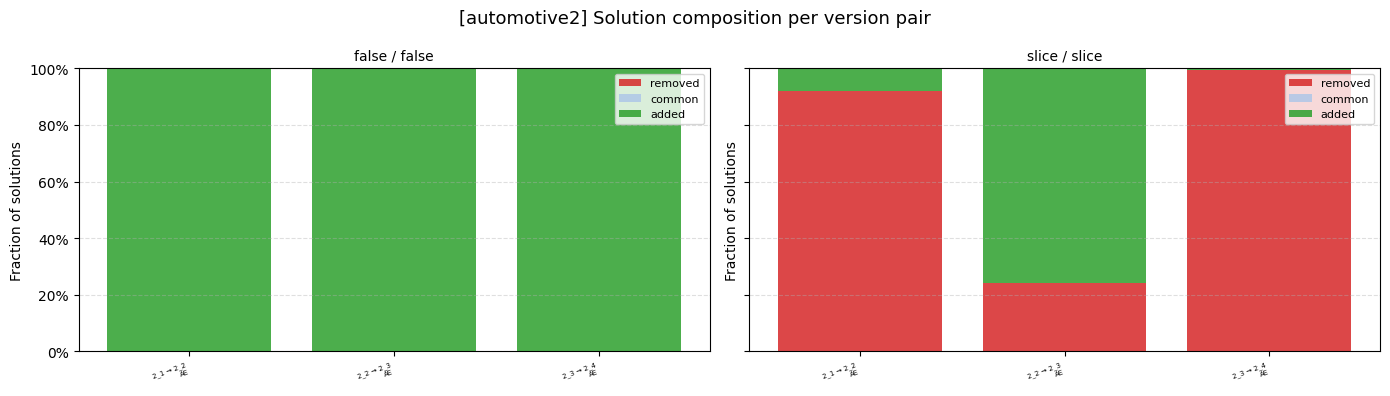

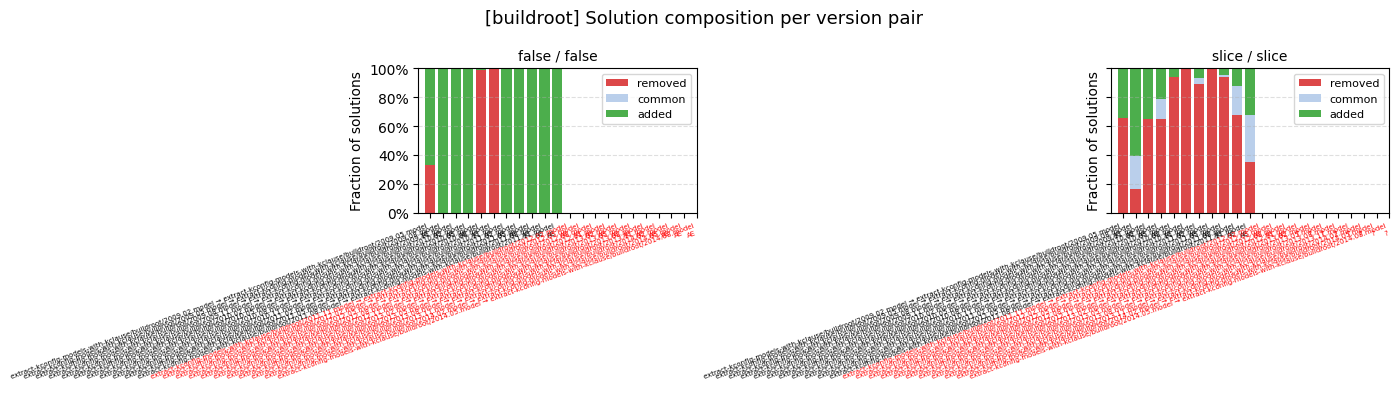

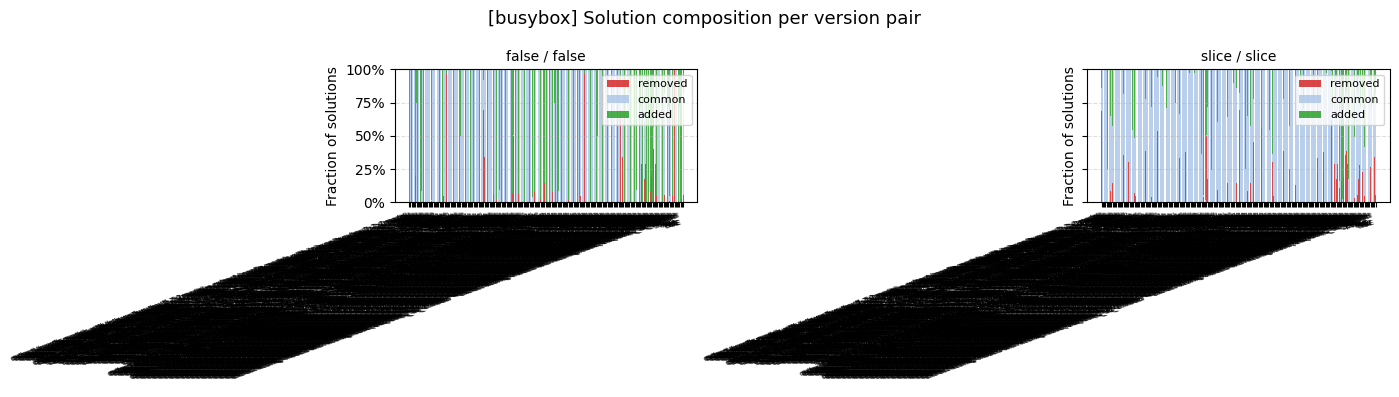

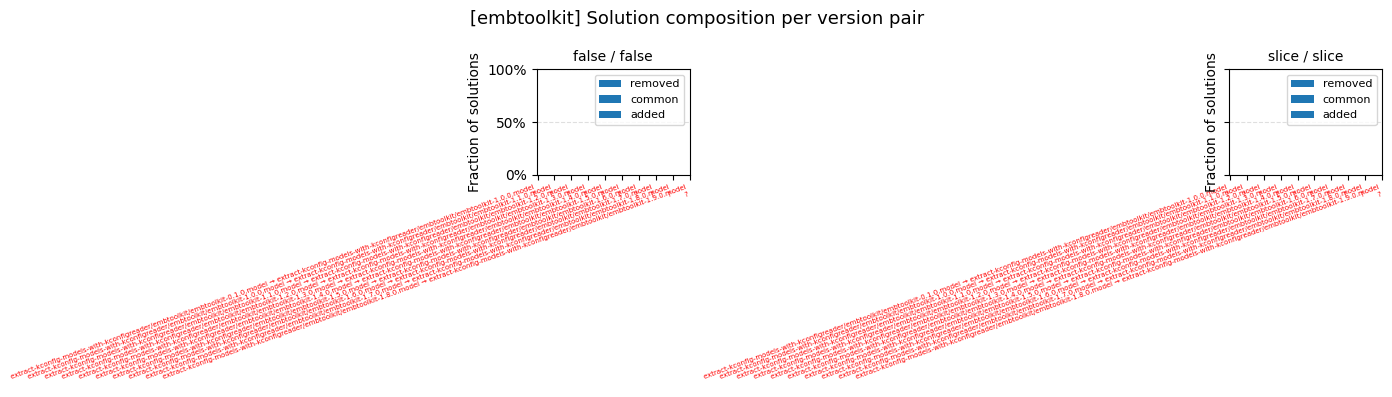

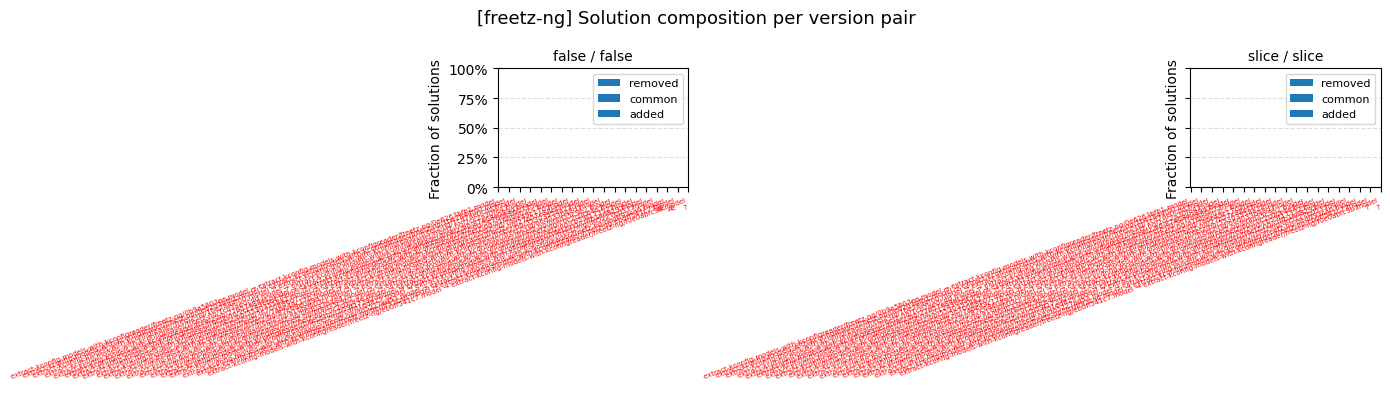

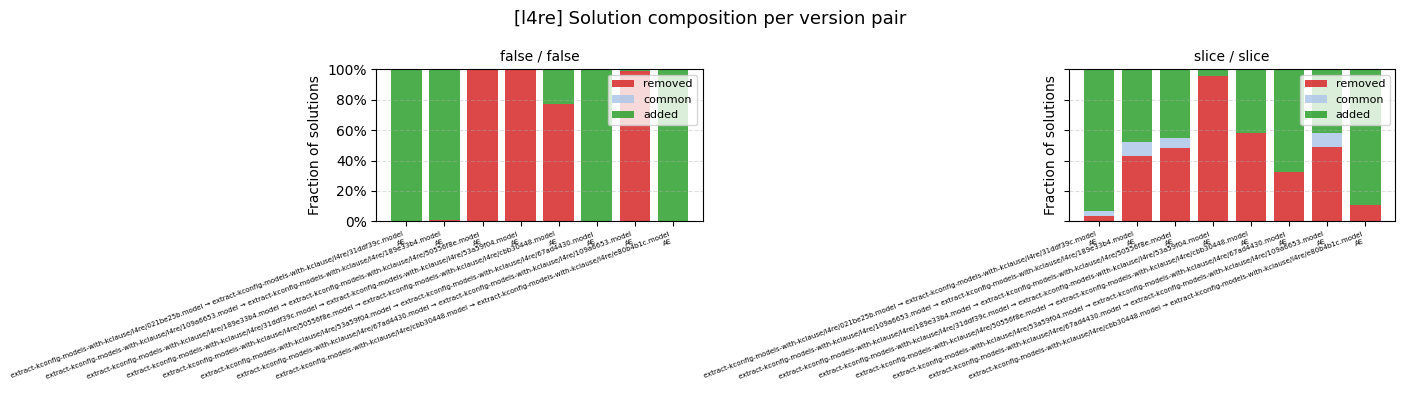

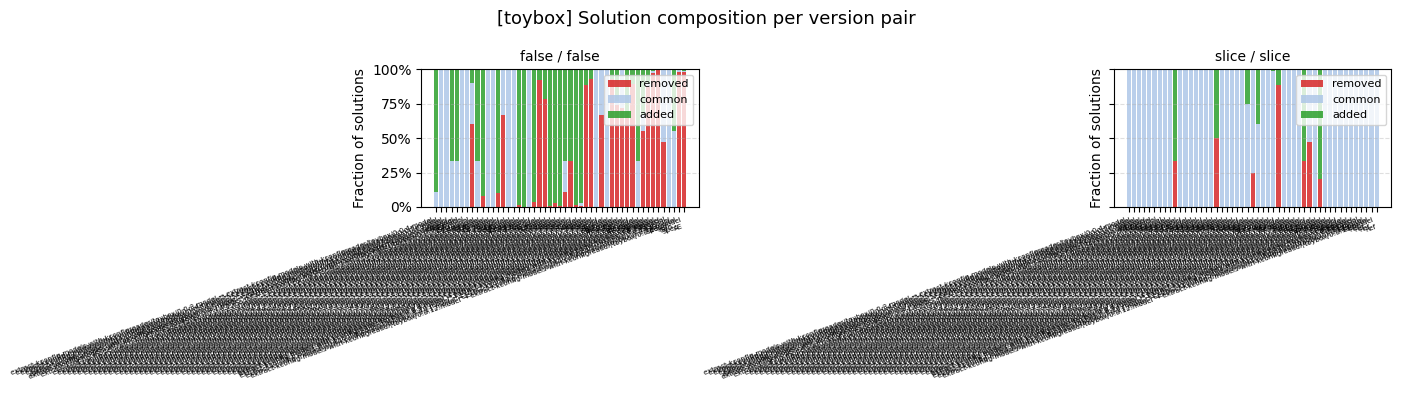

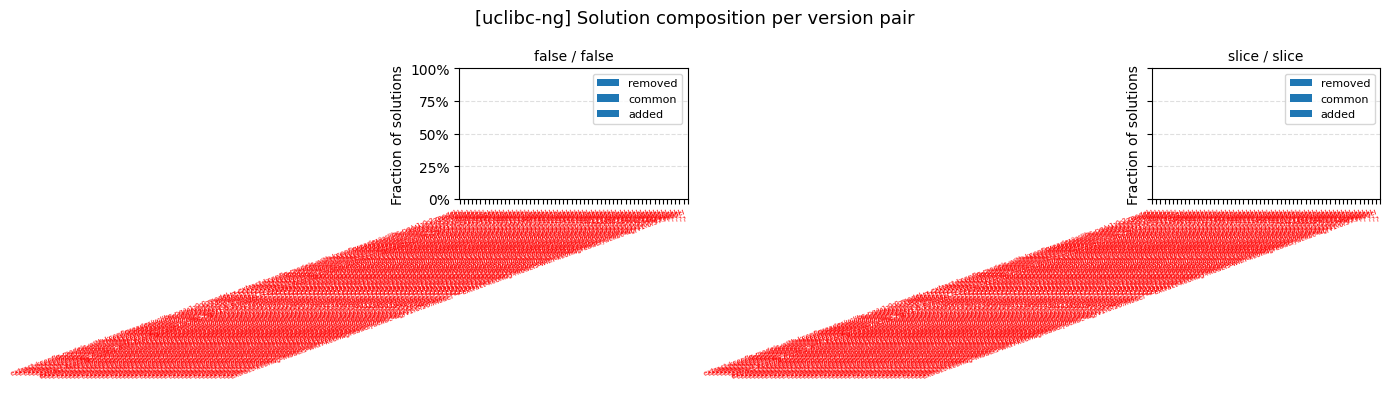

In [8]:
import re

def extract_version(filename):
    m = re.match(r'\d{14}-(?:[^-]+-)*v?(\d+[\._]\d+[\._]\d+)\.model$', filename)
    if m:
        return m.group(1).replace('_', '.')
    m = re.search(r'-(\d{4}-\d{2}-\d{2})\.xml$', filename)
    if m:
        return m.group(1)
    m = re.search(r'-(\d+_\d+)\.xml$', filename)
    if m:
        return m.group(1)
    m = re.match(r"v?(\d+[\._]\d+[\._]\d+)\[", filename)
    if m:
        return m.group(1).replace("_", ".")
    return filename

df['version_pair'] = (df['left_formula'].apply(extract_version)
                       + ' → ' + df['right_formula'].apply(extract_version))
df['diff_mode'] = (df['left_diff_kind'].astype(str)
                   + ' / ' + df['right_diff_kind'].astype(str))

comp_df = df[~((df['method'] == 'projected-count') & (df['negate'].astype(str) == 'True'))]

diff_modes = ['false / false', 'slice / slice']
comp_cols  = ['removed_solutions', 'common_solutions', 'added_solutions']

bar_colors = {'removed_solutions': '#d62728',
              'common_solutions':  '#aec7e8',
              'added_solutions':   '#2ca02c'}
label_map  = {'removed_solutions': 'removed',
              'common_solutions':  'common',
              'added_solutions':   'added'}

ABBREV = {'ArbitraryEdit': 'AE', 'Generalization': 'Gen',
          'Refactoring': 'Ref', 'Specialization': 'Spec'}

for system, sdf_comp in comp_df.groupby('system'):
    fig, axes = plt.subplots(1, len(diff_modes), figsize=(7 * len(diff_modes), 4), sharey=True)
    fig.suptitle(f'[{system}] Solution composition per version pair', fontsize=13)

    for ax, mode in zip(axes, diff_modes):
        mode_df = sdf_comp[sdf_comp['diff_mode'] == mode]

        # All version pairs sorted
        all_vp_sorted = (
            mode_df[['version_pair']]
            .drop_duplicates()
            .sort_values('version_pair',
                key=lambda s: s.apply(lambda x: (
                    [(int(p), '') if p.isdigit() else (0, p)
                     for p in re.split(r'[._-]', x.split(' → ')[0])]
                )))
            ['version_pair'].tolist()
        )

        # Best (first non-NaN) classification per version pair
        vp_class = (
            mode_df.dropna(subset=['classification'])
            .drop_duplicates(subset=['version_pair'])
            .set_index('version_pair')['classification']
        )

        # Version pairs with computed solution composition
        data_df = (
            mode_df[['version_pair'] + comp_cols]
            .dropna(subset=comp_cols)
            .drop_duplicates(subset=['version_pair'])
        )
        for c in comp_cols:
            data_df[c] = data_df[c].astype(float)
        data_dict = data_df.set_index('version_pair')[comp_cols].to_dict('index')

        vp   = all_vp_sorted
        clsf = [vp_class.get(v, '?') for v in vp]
        x    = np.arange(len(vp))

        bottom = np.zeros(len(vp))
        legend_added = set()
        for col in comp_cols:
            vals = np.array([data_dict[v][col] if v in data_dict else np.nan for v in vp])
            valid = ~np.isnan(vals)
            lbl = label_map[col] if col not in legend_added else '_nolegend_'
            legend_added.add(col)
            ax.bar(x[valid], vals[valid], bottom=bottom[valid],
                   label=lbl, color=bar_colors[col], alpha=0.85)
            bottom[valid] += vals[valid]

        ax.set_xticks(x)
        ax.set_xticklabels([f'{v}\n{ABBREV.get(c, c)}' for v, c in zip(vp, clsf)],
                           rotation=20, ha='right', fontsize=5)
        for tick, v in zip(ax.get_xticklabels(), vp):
            if v not in data_dict:
                tick.set_color('red')

        ax.set_title(mode, fontsize=10)
        ax.set_ylabel('Fraction of solutions')
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
        ax.set_ylim(0, 1)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

## 10. Correctness evaluation

In [9]:
import re

def extract_version(f):
    m = re.match(r'\d{14}-(?:[^-]+-)*v?(\d+[\._]\d+[\._]\d+)\.model$', f)
    if m:
        return m.group(1).replace('_', '.')
    m = re.search(r'-(\d{4}-\d{2}-\d{2})\.xml$', f)
    if m:
        return m.group(1)
    m = re.search(r'-(\d+_\d+)\.xml$', f)
    if m:
        return m.group(1)
    return f

df['version_pair'] = (df['left_formula'].apply(extract_version)
                       + ' → ' + df['right_formula'].apply(extract_version))
df['diff_mode'] = (df['left_diff_kind'].astype(str)
                   + ' / ' + df['right_diff_kind'].astype(str))

comp_cols = ['removed_solutions', 'common_solutions', 'added_solutions']
for c in comp_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

def expected_rows(sdf, diff_mode):
    mask = sdf['diff_mode'] == diff_mode
    if diff_mode == 'slice / slice':
        mask &= ~((sdf['method'] == 'projected-count') & (sdf['negate'].astype(str) == 'True'))
    return sdf[mask].dropna(subset=comp_cols)

for system, sdf in df.groupby('system'):
    print(f'\n{"="*60}')
    print(f'SYSTEM: {system}')
    print(f'{"="*60}')
    all_ok = True
    for mode in ['false / false', 'slice / slice']:
        print(f'\n=== {mode} — should-agree rows ===')
        sub = expected_rows(sdf, mode)
        for vp, g in sub.groupby('version_pair'):
            uniq = g[comp_cols].drop_duplicates()
            if len(uniq) > 1:
                all_ok = False
                print(f'  MISMATCH  {vp}:')
                for _, row in uniq.iterrows():
                    print(f'    removed={row.removed_solutions:.4f}  '
                          f'common={row.common_solutions:.4f}  '
                          f'added={row.added_solutions:.4f}')
            else:
                print(f'  OK  {vp}')

    if all_ok:
        print('\nAll should-agree groups are consistent.')

    print('\n=== slice / slice — projected-count + negate=True deviation from consensus ===')
    consensus = (
        expected_rows(sdf, 'slice / slice')
        .groupby('version_pair')[comp_cols]
        .first()
    )
    neg_rows = sdf[
        (sdf['diff_mode'] == 'slice / slice') &
        (sdf['method'] == 'projected-count') &
        (sdf['negate'].astype(str) == 'True')
    ].dropna(subset=comp_cols)

    for vp, g in neg_rows.groupby('version_pair'):
        if vp not in consensus.index:
            print(f'  {vp}: no consensus to compare against')
            continue
        ref = consensus.loc[vp]
        for _, row in g[['engine'] + comp_cols].drop_duplicates().iterrows():
            delta = {c: abs(row[c] - ref[c]) for c in comp_cols}
            max_d = max(delta.values())
            print(f'  {vp}  engine={row.engine}  '
                  f'Δremoved={delta["removed_solutions"]:.4f}  '
                  f'Δcommon={delta["common_solutions"]:.4f}  '
                  f'Δadded={delta["added_solutions"]:.4f}  '
                  f'max_Δ={max_d:.4f}')

    print('\n=== false / false — projected-count + negate=True (should also agree) ===')
    ff_neg = sdf[
        (sdf['diff_mode'] == 'false / false') &
        (sdf['method'] == 'projected-count') &
        (sdf['negate'].astype(str) == 'True')
    ].dropna(subset=comp_cols)
    consensus_ff = expected_rows(sdf, 'false / false').groupby('version_pair')[comp_cols].first()
    for vp, g in ff_neg.groupby('version_pair'):
        if vp not in consensus_ff.index:
            continue
        ref = consensus_ff.loc[vp]
        for _, row in g[['engine'] + comp_cols].drop_duplicates().iterrows():
            delta = {c: abs(row[c] - ref[c]) for c in comp_cols}
            max_d = max(delta.values())
            if max_d > 1e-10:
                print(f'  MISMATCH {vp}  engine={row.engine}  max_Δ={max_d:.6f}')
            else:
                print(f'  OK  {vp}  engine={row.engine}')


SYSTEM: FinancialServices01

=== false / false — should-agree rows ===
  OK  2017-05-22 → 2017-09-28
  OK  2017-09-28 → 2017-10-20
  OK  2017-10-20 → 2017-11-20
  OK  2017-11-20 → 2017-12-22
  OK  2017-12-22 → 2018-01-23
  OK  2018-01-23 → 2018-02-20
  OK  2018-02-20 → 2018-03-26
  OK  2018-03-26 → 2018-04-23
  OK  2018-04-23 → 2018-05-09

=== slice / slice — should-agree rows ===
  OK  2017-05-22 → 2017-09-28
  OK  2017-09-28 → 2017-10-20
  OK  2017-10-20 → 2017-11-20
  OK  2017-11-20 → 2017-12-22
  OK  2017-12-22 → 2018-01-23
  OK  2018-01-23 → 2018-02-20
  OK  2018-02-20 → 2018-03-26
  OK  2018-03-26 → 2018-04-23
  OK  2018-04-23 → 2018-05-09

All should-agree groups are consistent.

=== slice / slice — projected-count + negate=True deviation from consensus ===
  2017-05-22 → 2017-09-28  engine=d4-counting  Δremoved=0.3150  Δcommon=0.6100  Δadded=0.2950  max_Δ=0.6100
  2017-05-22 → 2017-09-28  engine=d4-proj-ddnnf-compiler  Δremoved=0.3150  Δcommon=0.6100  Δadded=0.2950  max_Δ=0.61

## 11. Timeout analysis — where does the algorithm time out?

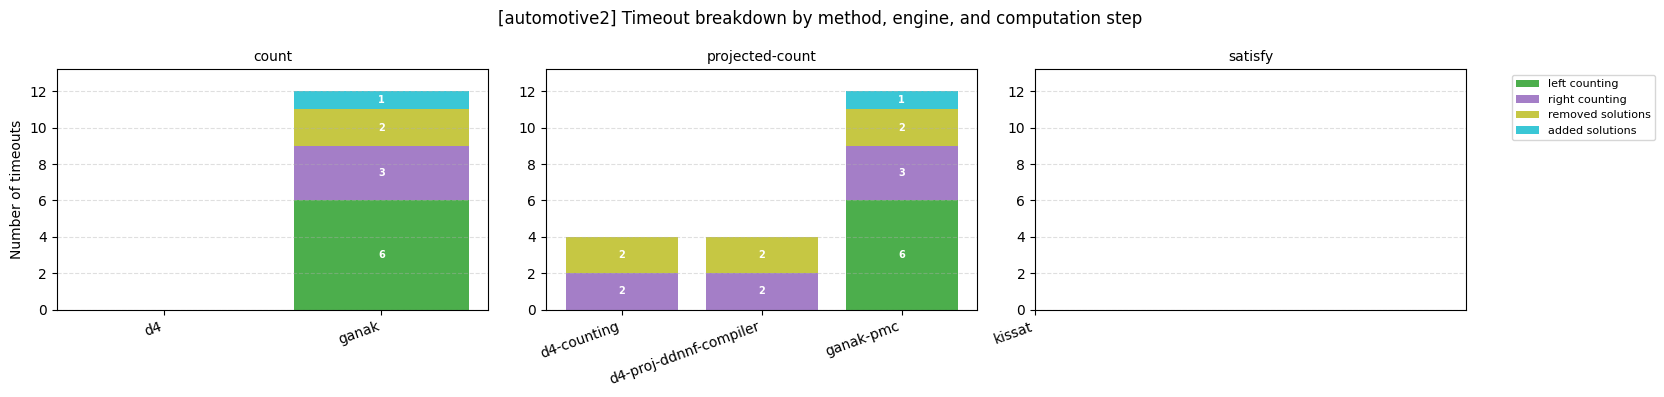

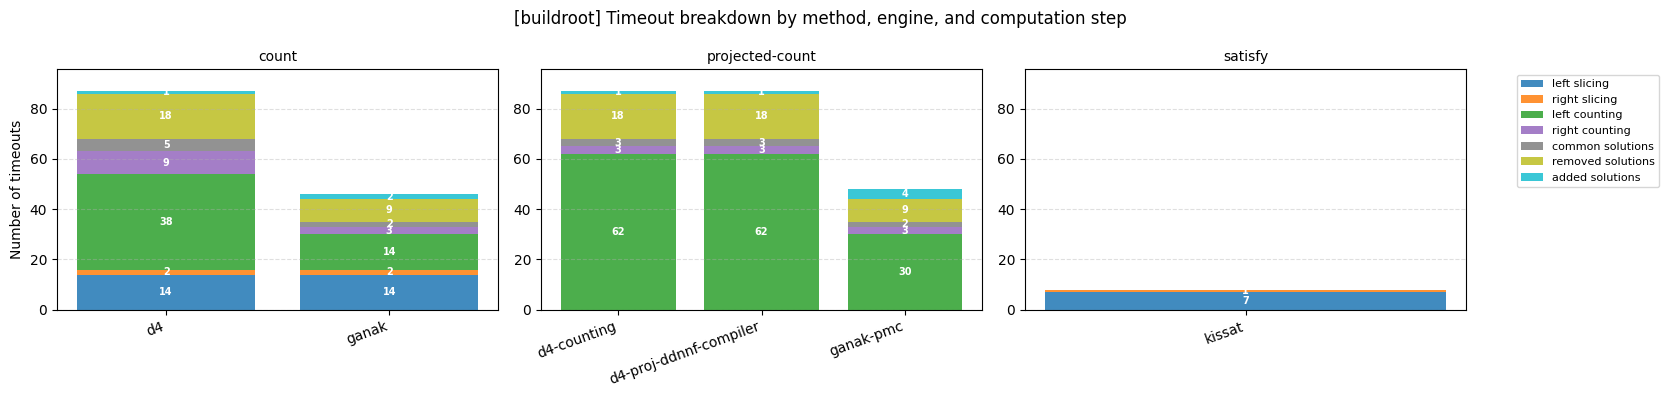

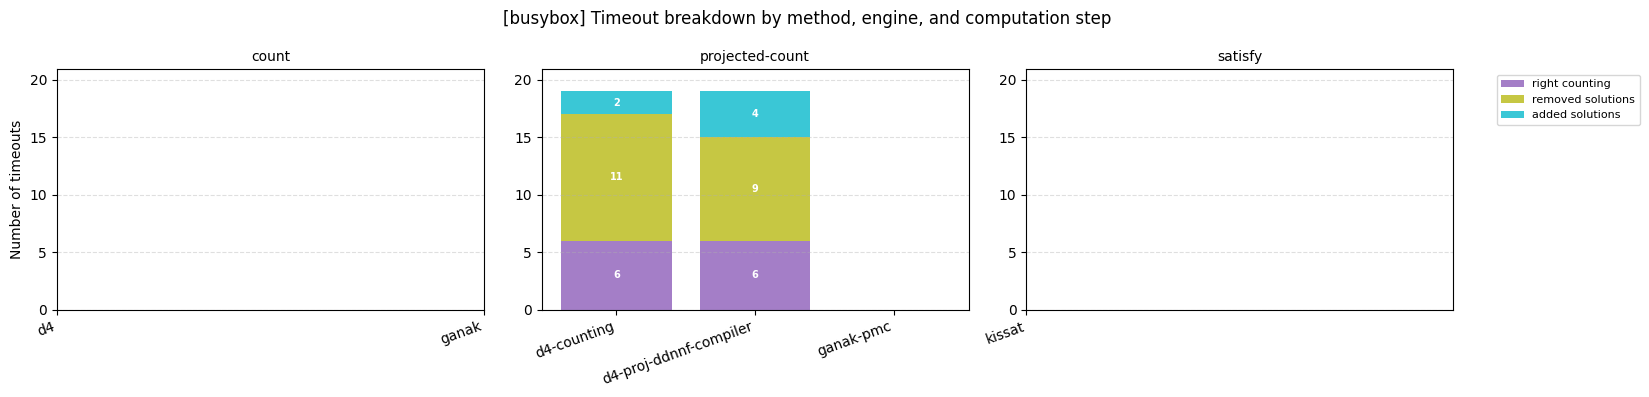

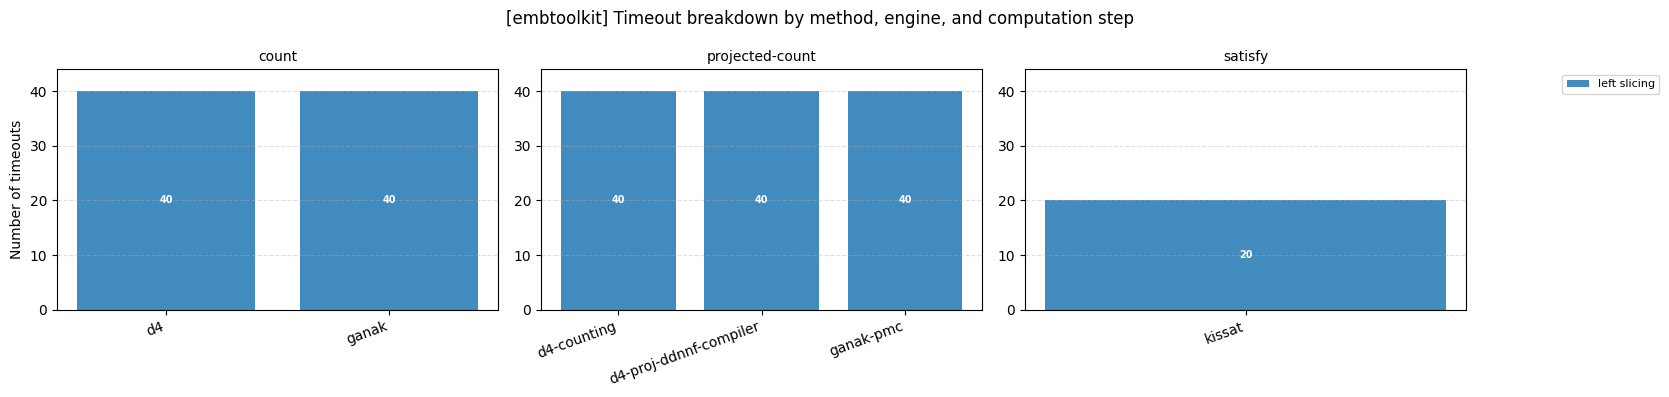

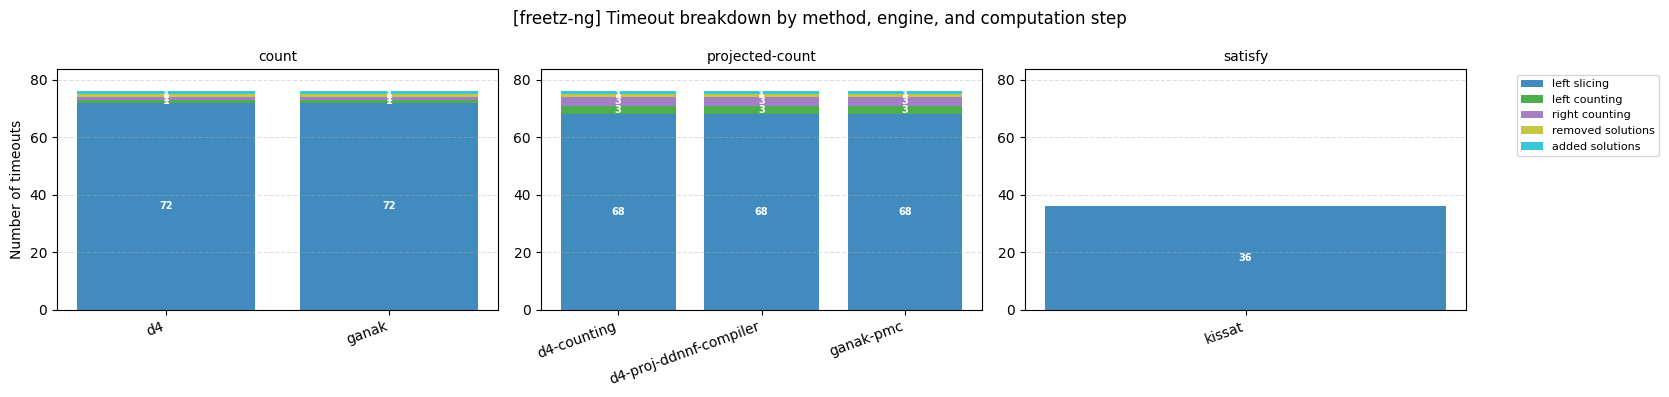

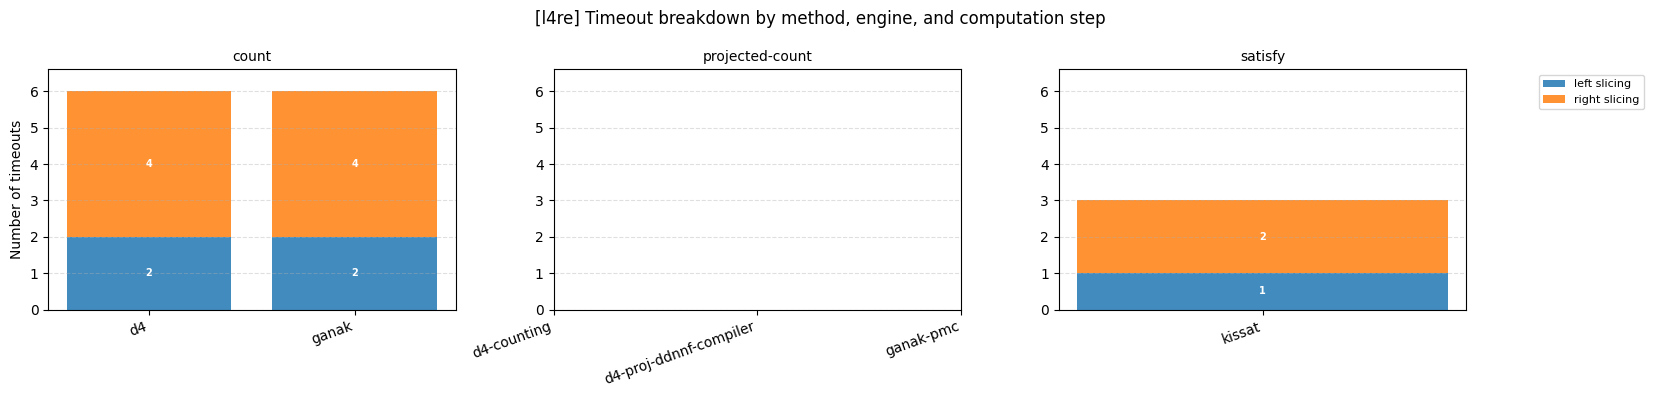

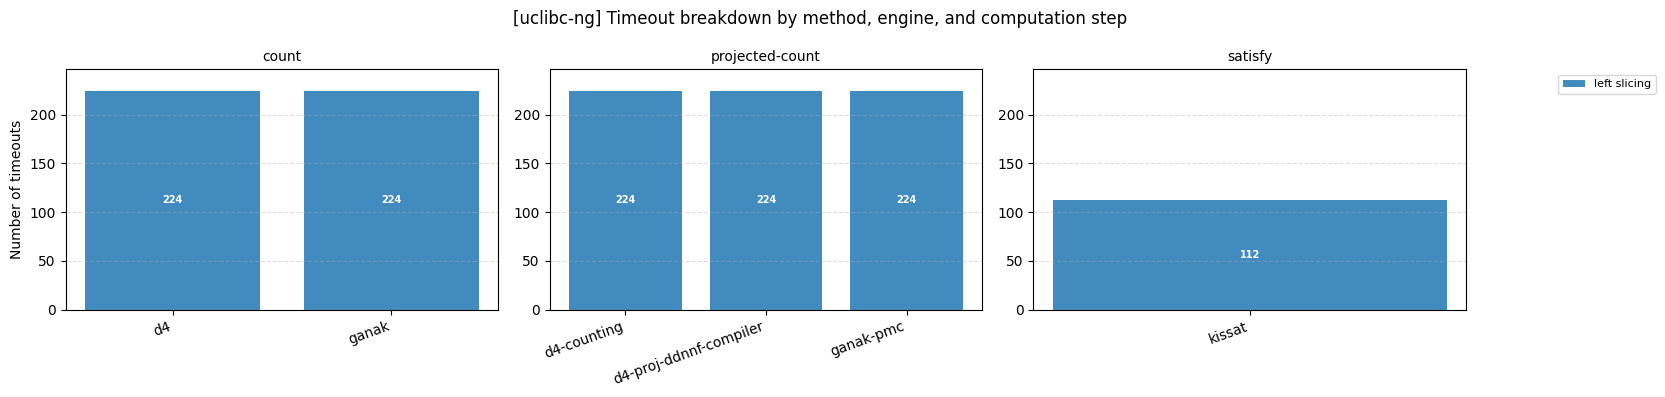

In [10]:
_dur_cols = [
    'left_sliced_duration',
    'right_sliced_duration',
    'left_count_duration',
    'left_sliced_count_duration',
    'right_count_duration',
    'right_sliced_count_duration',
    'tseitin_or_featureide_duration',
    'common_solutions_count_duration',
    'removed_solutions_count_duration',
    'added_solutions_count_duration',
]
_step_labels = {
    'left_sliced_duration':            'left slicing',
    'right_sliced_duration':           'right slicing',
    'left_count_duration':             'left counting',
    'left_sliced_count_duration':      'left counting',
    'right_count_duration':            'right counting',
    'right_sliced_count_duration':     'right counting',
    'tseitin_or_featureide_duration':  'CNF transform',
    'common_solutions_count_duration': 'common solutions',
    'removed_solutions_count_duration':'removed solutions',
    'added_solutions_count_duration':  'added solutions',
}

def _find_timeout_step(row):
    if pd.notna(row['total_duration']):
        return None
    for col in _dur_cols:
        if pd.isna(row[col]):
            return _step_labels[col]
    return 'unknown'

df['timeout_step'] = df.apply(_find_timeout_step, axis=1)

all_steps   = ['left slicing', 'right slicing', 'left counting', 'right counting',
               'CNF transform', 'common solutions', 'removed solutions', 'added solutions']
step_colors = dict(zip(all_steps, plt.cm.tab10(np.linspace(0, 1, len(all_steps)))))

for system, sdf in df.groupby('system'):
    methods = sorted(sdf['method'].unique())
    tout_df = sdf[sdf['timeout_step'].notna()]

    if tout_df.empty:
        continue

    fig, axes = plt.subplots(1, len(methods),
                             figsize=(5.5 * len(methods), 4),
                             squeeze=False)
    fig.suptitle(f'[{system}] Timeout breakdown by method, engine, and computation step', fontsize=12)

    y_max = 0
    for ax, method in zip(axes[0], methods):
        sub = tout_df[tout_df['method'] == method]
        present_engines = sorted(sdf[sdf['method'] == method]['engine'].unique())

        counts = (
            sub.groupby(['engine', 'timeout_step'])
            .size()
            .unstack(fill_value=0)
            .reindex(index=present_engines, columns=all_steps, fill_value=0)
        )
        counts = counts.loc[:, (counts > 0).any(axis=0)]

        x = np.arange(len(present_engines))
        bottom = np.zeros(len(present_engines))
        for step in counts.columns:
            vals = counts[step].values
            ax.bar(x, vals, bottom=bottom, label=step,
                   color=step_colors[step], alpha=0.85)
            for xi, (v, b) in enumerate(zip(vals, bottom)):
                if v > 0:
                    ax.text(xi, b + v / 2, str(v), ha='center', va='center',
                            fontsize=7, color='white', fontweight='bold')
            bottom += vals

        y_max = max(y_max, bottom.max())
        ax.set_xticks(x)
        ax.set_xticklabels(present_engines, rotation=20, ha='right')
        ax.set_title(method, fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    for ax in axes[0]:
        ax.set_ylim(top=y_max * 1.1)
    axes[0][0].set_ylabel('Number of timeouts')

    handles = [plt.matplotlib.patches.Patch(facecolor=step_colors[s], alpha=0.85, label=s)
               for s in all_steps if s in tout_df['timeout_step'].values]
    axes[0][-1].legend(handles=handles, fontsize=8, loc='upper right', bbox_to_anchor=(1.45, 1))
    plt.tight_layout()
    plt.show()